# Coffee Survey Analysis

## Overview
This project analyzes coffee consumption preferences using survey data from over 4,000 respondents.

## Objectives
- Understand consumer behavior
- Identify preference patterns
- Generate business insights

## Dataset
The Great Coffee Taste Test (TidyTuesday)

**Tools used:** Python, Pandas, Matplotlib

## Data Collection

The dataset is retrieved from an online repository.  
In this step, we download and store the dataset locally for further analysis.

In [ ]:
import requests

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2024/2024-05-14/coffee_survey.csv"
output_file = "coffee_survey.csv"


def download_csv(url, output_file):
    print("Downloading file...")
    response = requests.get(url)

    print("Saving file...")
    with open(output_file, "w", encoding="utf-8") as file:
        file.write(response.content.decode("utf-8"))

    print("File downloaded successfully!")


download_csv(url, output_file)

Saving file...
File downloaded successfully!


## Data Loading

The dataset is loaded into a pandas DataFrame for further exploration and analysis.

In [ ]:
import pandas as pd

df = pd.read_csv("coffee_survey.csv")
df.head()

,submission_id,age,cups,where_drink,brew,brew_other,purchase,purchase_other,favorite,favorite_specify,...,spent_equipment,value_equipment,gender,gender_specify,education_level,ethnicity_race,ethnicity_race_specify,employment_status,number_children,political_affiliation
0,gMR29l,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BkPN0e,25-34 years old,NaN,NaN,Pod/capsule machine (e.g. Keurig/Nespresso),NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W5G8jj,25-34 years old,NaN,NaN,Bean-to-cup machine,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4xWgGr,35-44 years old,NaN,NaN,Coffee brewing machine (e.g. Mr. Coffee),NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,QD27Q8,25-34 years old,NaN,NaN,Pour over,NaN,NaN,NaN,Latte,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Inspection

Before performing the analysis, we inspect the dataset to understand its structure, data types, and potential missing values.

In [ ]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4042 entries, 0 to 4041
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   submission_id                 4042 non-null   object 
 1   age                           4011 non-null   object 
 2   cups                          3949 non-null   object 
 3   where_drink                   3972 non-null   object 
 4   brew                          3657 non-null   object 
 5   brew_other                    678 non-null    object 
 6   purchase                      710 non-null    object 
 7   purchase_other                31 non-null     object 
 8   favorite                      3980 non-null   object 
 9   favorite_specify              114 non-null    object 
 10  additions                     3959 non-null   object 
 11  additions_other               48 non-null     object 
 12  dairy                         1686 non-null   object 
 13  swe

,submission_id,age,cups,where_drink,brew,brew_other,purchase,purchase_other,favorite,favorite_specify,...,spent_equipment,value_equipment,gender,gender_specify,education_level,ethnicity_race,ethnicity_race_specify,employment_status,number_children,political_affiliation
count,4042,4011,3949,3972,3657,678,710,31,3980,114,...,3506,3494,3523,12,3438,3418,105,3419,856,3289
unique,4042,7,6,65,449,160,89,26,12,77,...,7,2,5,11,6,6,82,6,4,4
top,0EGYe9,25-34 years old,2,At home,Pour over,Aeropress,Specialty coffee shop,Online,Pourover,Aeropress,...,"More than $1,000",Yes,Male,Transgender Female,Bachelor's degree,White/Caucasian,Mixed,Employed full-time,2,Democrat
freq,1,1986,1663,1625,575,335,116,2,1084,9,...,780,3318,2524,2,1759,2626,7,2708,402,1768
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Age Distribution

This section explores how respondents are distributed across different age groups.

In [ ]:
age_distribution = df['age'].value_counts().reset_index()
age_distribution.columns = ['Age Range', 'Respondents']

age_distribution

,Age Range,Respondents
0,25-34 years old,1986
1,35-44 years old,960
2,18-24 years old,461
3,45-54 years old,302
4,55-64 years old,187
5,>65 years old,95
6,<18 years old,20


### Insight

The majority of respondents fall within the young adult segment, particularly in the 25–34, 35–44, and 18–24 age groups.

This suggests higher engagement and coffee consumption among these demographics.

## Handling Multi-Value Columns

Some columns contain multiple responses per participant (e.g., places where coffee is consumed).

To analyze these correctly, we split the values and expand them into individual rows.

In [ ]:
def process_column(df, column_name):
    series = df[column_name].dropna()
    result = (
        series.astype(str)
        .str.split(', ')
        .explode()
        .value_counts()
        .reset_index()
    )
    result.columns = [column_name, 'Respondent_Count']
    return result


def process_column_flexible(df, column_name):
    filtered = df[
        df[column_name].notna() & (df[column_name] != 'NA')
    ].copy()

    is_multiple = filtered[column_name].str.contains(', ', na=False).any()

    if is_multiple:
        filtered['options'] = filtered[column_name].str.split(', ')
        count = filtered.explode('options')['options'].value_counts()
    else:
        count = filtered[column_name].value_counts()

    frequency = count.reset_index()
    frequency.columns = [column_name, 'Respondent_Count']

    return frequency

In [ ]:
process_column(df, "age")
process_column(df, "favorite")

process_column_flexible(df, "where_drink")

,where_drink,Respondent_Count
0,At home,3644
1,At the office,1430
2,At a cafe,1170
3,On the go,705
4,None of these,36


## Data Filtering

We define a function to filter the dataset based on specific column values.

In [ ]:
def filter_by_value(df, column, value):
    return df[df[column] == value]


filter_by_value(df, 'gender', 'Female').head(5)
filter_by_value(df, 'gender', 'Male').head(5)

,submission_id,age,cups,where_drink,brew,brew_other,purchase,purchase_other,favorite,favorite_specify,...,spent_equipment,value_equipment,gender,gender_specify,education_level,ethnicity_race,ethnicity_race_specify,employment_status,number_children,political_affiliation
34,ylqbBg,45-54 years old,2,"At home, At the office, At a cafe, On the go","Pour over, French press, Espresso",NaN,"Local cafe, Specialty coffee shop",NaN,Regular drip coffee,NaN,...,$500-$1000,Yes,Male,NaN,Master's degree,Other (please specify),Mix,Employed full-time,2,No affiliation
41,YZzBdN,25-34 years old,2,"At home, At the office","Pour over, Espresso",NaN,NaN,NaN,Pourover,NaN,...,$50-$100,Yes,Male,NaN,Master's degree,Asian/Pacific Islander,NaN,Unemployed,NaN,Independent
42,VZ17Z6,35-44 years old,1,"At the office, At home",Pour over,NaN,NaN,NaN,Iced coffee,NaN,...,$100-$300,Yes,Male,NaN,Bachelor's degree,White/Caucasian,NaN,Employed full-time,3,No affiliation
43,RzBeZj,45-54 years old,More than 4,At home,"Pour over, French press, Pod/capsule machine (...",NaN,NaN,NaN,Pourover,NaN,...,$300-$500,Yes,Male,NaN,Bachelor's degree,White/Caucasian,NaN,Employed full-time,3,No affiliation
46,WApbkQ,35-44 years old,2,"At a cafe, At home","Espresso, Pod/capsule machine (e.g. Keurig/Nes...",NaN,NaN,NaN,Cappuccino,NaN,...,"More than $1,000",Yes,Male,NaN,Less than high school,Black/African American,NaN,Unemployed,2,Independent


## Age Distribution (Visualization)

We visualize the proportion of respondents in each age group using a pie chart.

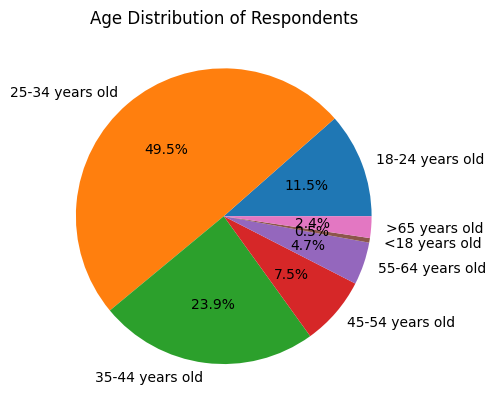

In [ ]:
import matplotlib.pyplot as plt

df.groupby('age').size().plot.pie(autopct='%1.1f%%')
plt.title('Age Distribution of Respondents')
plt.ylabel('')
plt.show()

## Coffee Preferences by Age Group

We analyze how coffee preferences vary across different age groups.

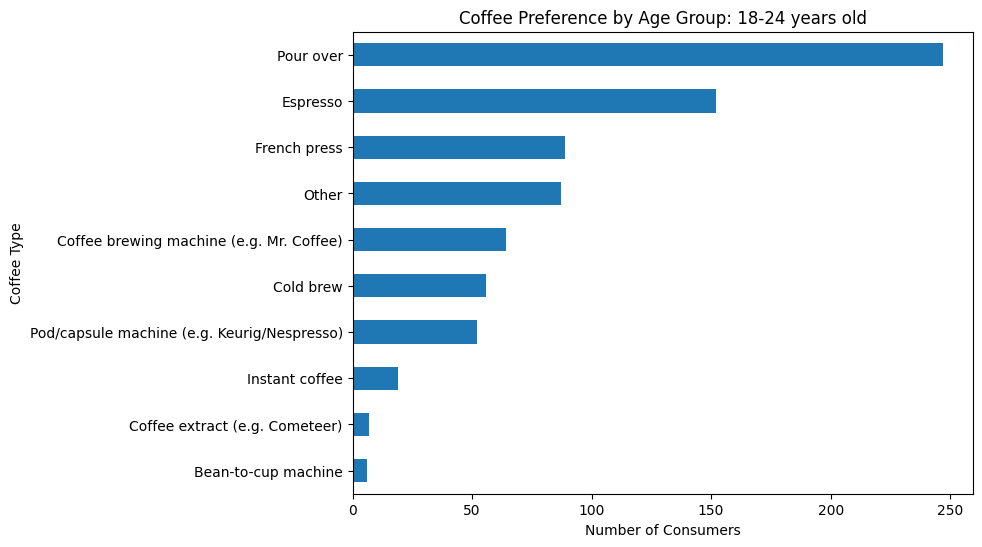

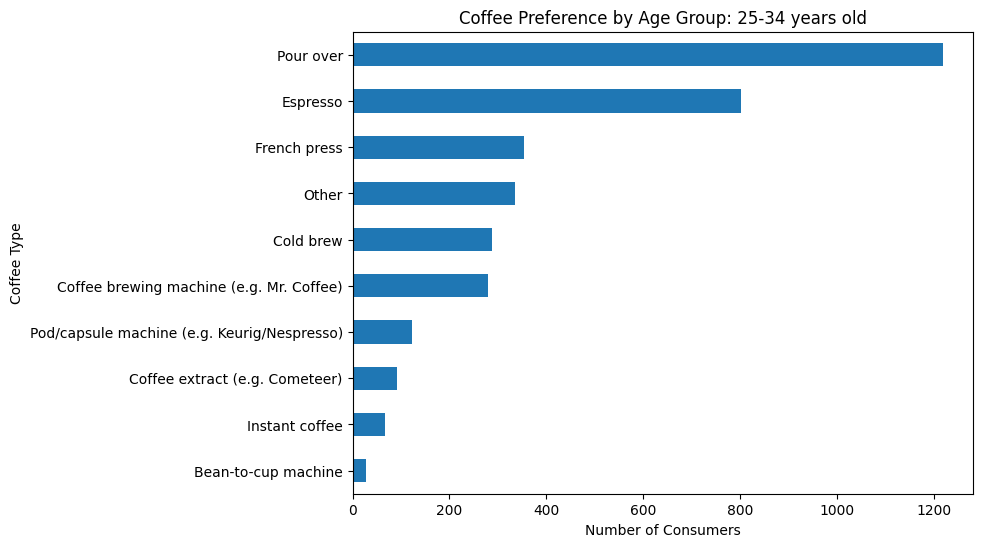

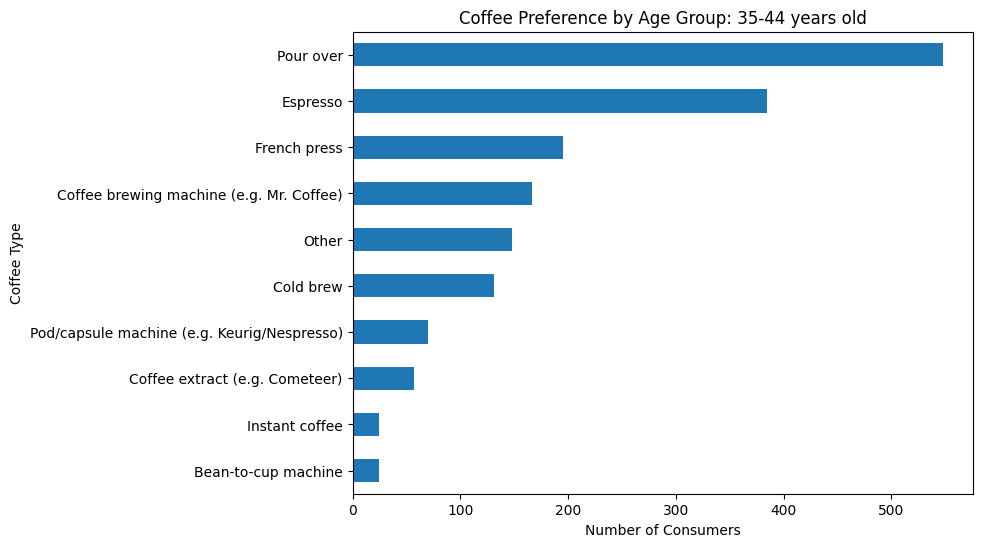

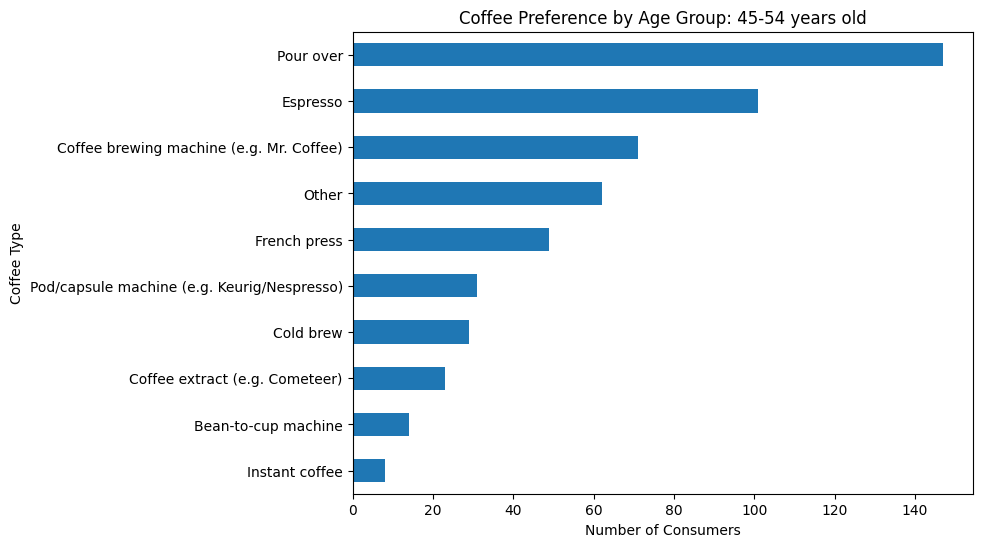

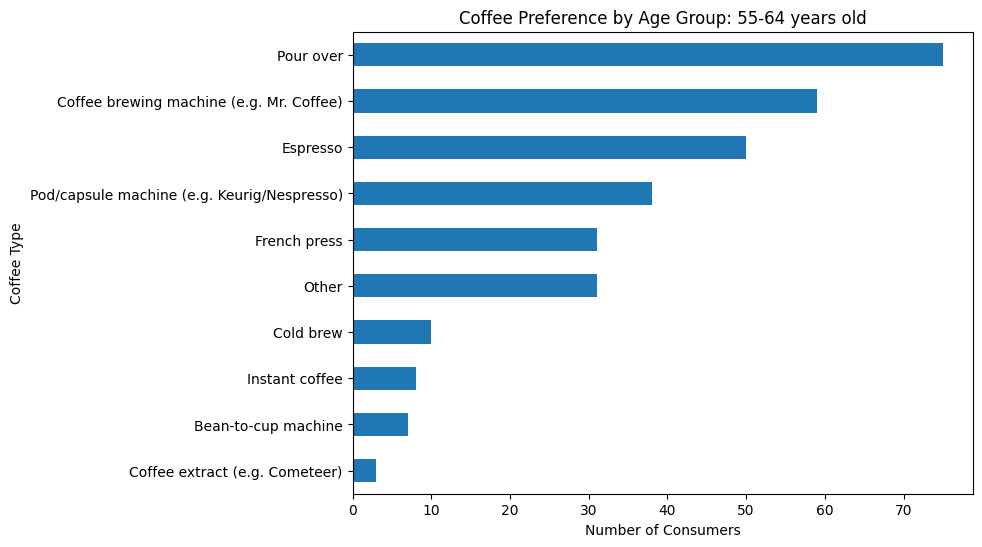

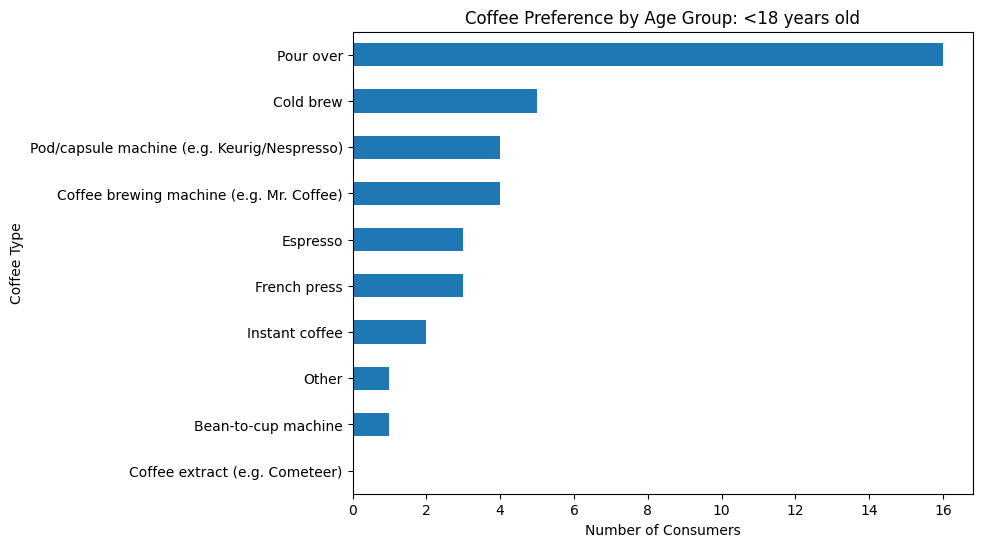

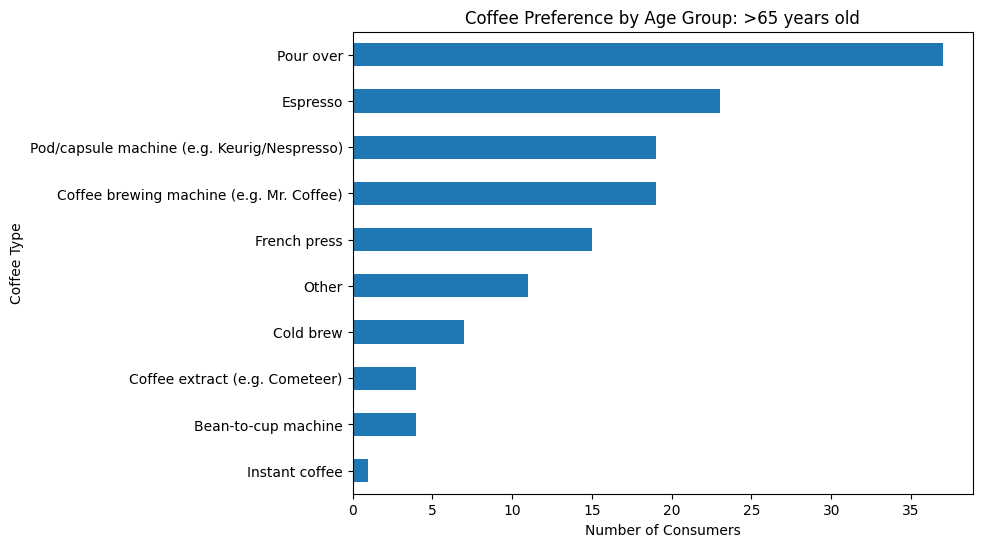

In [ ]:
df_exp = df.copy()
df_exp['brew'] = df_exp['brew'].str.split(', ')
df_exp = df_exp.explode('brew')

table = df_exp.groupby(['age', 'brew']).size().unstack(fill_value=0)

for group in table.index:
    data = table.loc[group].sort_values()

    data.plot(kind='barh', figsize=(8, 6))
    plt.title(f'Coffee Preference by Age Group: {group}')
    plt.xlabel('Number of Consumers')
    plt.ylabel('Coffee Type')
    plt.show()

## Education Level Analysis

We identify the most common education level among respondents.

In [ ]:
most_common_education = df['education_level'].mode()[0]
print(f'Most common education level: {most_common_education}')

Most common education level: Bachelor's degree


## Conclusions

The analysis shows that most coffee consumers belong to the young adult segment (25–34 years old).

Drip coffee dominates across most age groups, while beverages such as frappuccino, cold brew, and iced coffee are less popular.

Additionally, most respondents have a bachelor's degree, suggesting a customer base that may value calm and comfortable environments.

---

## Recommendations

- Focus marketing on the 25–34 age segment
- Use platforms such as Instagram and TikTok
- Highlight best-selling products
- Promote under-consumed products through campaigns
- Offer tastings and workshops
- Design a comfortable, study-friendly environment